In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")
import os
from huggingface_hub import login

login(token=secret_value_0)

In [2]:
%%capture
!pip install -q transformers>=4.43.0 datasets accelerate bitsandbytes huggingface_hub

In [3]:
!wget https://rome.baulab.info/data/dsets/counterfact.json

--2026-05-23 06:28:10--  https://rome.baulab.info/data/dsets/counterfact.json
Resolving rome.baulab.info (rome.baulab.info)... 35.232.255.106
Connecting to rome.baulab.info (rome.baulab.info)|35.232.255.106|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45108470 (43M) [application/json]
Saving to: ‘counterfact.json’

counterfact.json    100%[===================>]  43.02M   117MB/s    in 0.4s    

2026-05-23 06:28:11 (117 MB/s) - ‘counterfact.json’ saved [45108470/45108470]



In [4]:
import os, json, time, gc, warnings, urllib.request
from copy import deepcopy
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [5]:
@dataclass
class MEMITConfig:
    model_name         : str       = 'meta-llama/Llama-3.2-1B'
    # critical MLP layers R (paper §4.1) — LLaMA 3.2-1B has 16 layers
    layers             : List[int] = field(default_factory=lambda: [6,7,8,9,10,11])
    mlp_module_tmp     : str       = 'model.layers.{}.mlp.down_proj'
    layer_module_tmp   : str       = 'model.layers.{}'
    # z optimisation (Stage 1)
    v_num_grad_steps   : int       = 100
    v_lr               : float     = 0.01
    v_weight_decay     : float     = 0.05
    kl_factor          : float     = 0.0625
    clamp_norm_factor  : float     = 4.0
    # FIX 1 — number of random prefixes for z-target and key averaging (paper §4.2 Eq.16/19)
    v_num_prefixes     : int       = 5
    # covariance — lambda is AUTO-CALIBRATED below
    mom2_update_weight : float     = 1.0
    cov_n_texts        : int       = 1000
    cov_ridge_eps      : float     = 1e-2
    # batching
    batch_size         : int       = 10

CFG     = MEMITConfig()
N_EDITS = 10
EVAL_N  = 10

# Prefix bank — used to average z-targets and keys over P contexts (paper Eq.16/19)
PREFIX_BANK = [
    "",
    "As we know, ",
    "It is well established that ",
    "According to available information, ",
    "Historically speaking, ",
    "In fact, ",
    "It has been documented that ",
    "Based on records, ",
    "To be precise, ",
    "It is commonly known that ",
]

print('Config OK')

Config OK


In [6]:
from kaggle_secrets import UserSecretsClient
try:
    os.environ['HUGGING_FACE_HUB_TOKEN'] = UserSecretsClient().get_secret('HF_TOKEN')
    print('HF token ✓')
except Exception:
    print('No HF_TOKEN secret — add via Add-ons → Secrets')

tokenizer = AutoTokenizer.from_pretrained(CFG.model_name)
tokenizer.pad_token = tokenizer.eos_token

# device_map={'':0} forces every layer onto cuda:0
# NEVER use device_map='auto' on Kaggle — causes phantom multi-device splits
model = AutoModelForCausalLM.from_pretrained(
    CFG.model_name, torch_dtype=torch.float16, device_map={'': 0})
model.eval()

devices = {p.device for p in model.parameters()}
assert len(devices) == 1, f'Model split: {devices}'
GPU0 = next(iter(devices))
print(f'Model on {GPU0}  |  VRAM={torch.cuda.memory_allocated()/1e9:.2f} GB')

HF token ✓


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Model on cuda:0  |  VRAM=2.47 GB


In [7]:
@dataclass
class CFRecord:
    case_id: int;  subject: str;  relation_id: str
    target_new: str;  ground_truth: str;  prompt: str
    rephrase_prompts: List[str]
    neighborhood_prompts: List[str]
    generation_prompts: List[str]

@dataclass
class EditRequest:
    subject: str;  target_new: str;  prompt: str;  ground_truth: str

CF_CACHE = '/kaggle/working/counterfact.json'
if not os.path.exists(CF_CACHE):
    print('Downloading CounterFact ...')
    urllib.request.urlretrieve('https://rome.baulab.info/data/dsets/counterfact.json', CF_CACHE)

with open(CF_CACHE) as f:
    raw_cf = json.load(f)
print(f'Total records: {len(raw_cf)}')

def parse_records(raw, n=None):
    data = raw[:n] if n else raw
    out  = []
    for item in data:
        req  = item.get('requested_rewrite', {})
        subj = req.get('subject', '')
        tt   = req.get('target_true', {})
        tn   = req.get('target_new',  {})
        out.append(CFRecord(
            case_id              = item.get('case_id', 0),
            subject              = subj,
            relation_id          = req.get('relation_id', ''),
            target_new           = tn.get('str','') if isinstance(tn, dict) else str(tn),
            ground_truth         = tt.get('str','') if isinstance(tt, dict) else str(tt),
            prompt               = req.get('prompt','{}').format(subj),
            rephrase_prompts     = item.get('paraphrase_prompts', []),
            neighborhood_prompts = item.get('neighborhood_prompts', []),
            generation_prompts   = item.get('generation_prompts', []),
        ))
    return out

records       = parse_records(raw_cf, n=N_EDITS)
edit_requests = [EditRequest(subject=r.subject, target_new=r.target_new,
                             prompt=r.prompt, ground_truth=r.ground_truth)
                 for r in records]
print(f'Loaded {len(records)} records')
print(f'Sample: prompt="{records[0].prompt}"  new="{records[0].target_new}"  old="{records[0].ground_truth}"')

Total records: 21919
Loaded 10 records
Sample: prompt="The mother tongue of Danielle Darrieux is"  new="English"  old="French"


In [8]:
def get_module(model, name: str):
    m = model
    for p in name.split('.'): m = getattr(m, p)
    return m

def get_last_subject_pos(prompt: str, subject: str) -> int:
    """Find token index of last subject token inside prompt. 4 fallback strategies."""
    prompt_ids = tokenizer(prompt, return_tensors='pt')['input_ids'][0]
    n = len(prompt_ids)

    # Strategy 1: exact token sequence match
    stoks = tokenizer(subject, add_special_tokens=False)['input_ids']
    for i in range(n - len(stoks), -1, -1):
        if prompt_ids[i : i+len(stoks)].tolist() == stoks:
            return i + len(stoks) - 1

    # Strategy 2: match with leading space
    stoks2 = tokenizer(' ' + subject, add_special_tokens=False)['input_ids']
    for i in range(n - len(stoks2), -1, -1):
        if prompt_ids[i : i+len(stoks2)].tolist() == stoks2:
            return i + len(stoks2) - 1

    # Strategy 3: character-level search via offset mapping
    prompt_lower  = prompt.lower()
    subject_lower = subject.lower()
    char_pos = prompt_lower.rfind(subject_lower)
    if char_pos != -1:
        last_char = char_pos + len(subject) - 1
        enc     = tokenizer(prompt, return_tensors='pt', return_offsets_mapping=True)
        offsets = enc['offset_mapping'][0]
        for tok_idx in range(len(offsets)-1, -1, -1):
            start, end = offsets[tok_idx].tolist()
            if start <= last_char <= end:
                return tok_idx

    # Strategy 4: fallback — last token before common follow words
    follow_words = [' is', ' was', ' are', ' were', ' by',
                    ' of', ' in', ' at', ' ,', ' that', ' which']
    for fw in follow_words:
        idx = prompt.lower().rfind(fw)
        if idx != -1:
            enc     = tokenizer(prompt, return_tensors='pt', return_offsets_mapping=True)
            offsets = enc['offset_mapping'][0]
            for tok_idx in range(len(offsets)-1, -1, -1):
                start, end = offsets[tok_idx].tolist()
                if end <= idx:
                    return tok_idx

    print(f'  [WARN] subject "{subject}" not found in "{prompt}" — using last token')
    return n - 1

@torch.no_grad()
def token_log_prob(prompt: str, target: str) -> float:
    """Normalised log-prob of target tokens given prompt."""
    enc   = tokenizer(prompt + ' ' + target, return_tensors='pt').to(GPU0)
    p_len = tokenizer(prompt, return_tensors='pt')['input_ids'].shape[1]
    lp    = torch.log_softmax(model(**enc).logits[0], dim=-1)
    tids  = enc['input_ids'][0][p_len:]
    if len(tids) == 0: return 0.0
    return sum(lp[p_len-1+i, tid].item() for i, tid in enumerate(tids)) / len(tids)

print("Helpers ✓")


Helpers ✓


Clean P("French") = 0.4268
Corrupted P("French") = 0.0000
  Layer  0: recovery=0.001  
  Layer  1: recovery=0.001  
  Layer  2: recovery=0.000  
  Layer  3: recovery=0.000  
  Layer  4: recovery=0.000  
  Layer  5: recovery=0.000  
  Layer  6: recovery=-0.000  
  Layer  7: recovery=0.000  
  Layer  8: recovery=0.002  
  Layer  9: recovery=0.001  
  Layer 10: recovery=0.014  
  Layer 11: recovery=0.006  
  Layer 12: recovery=0.003  
  Layer 13: recovery=0.001  
  Layer 14: recovery=-0.000  
  Layer 15: recovery=-0.000  


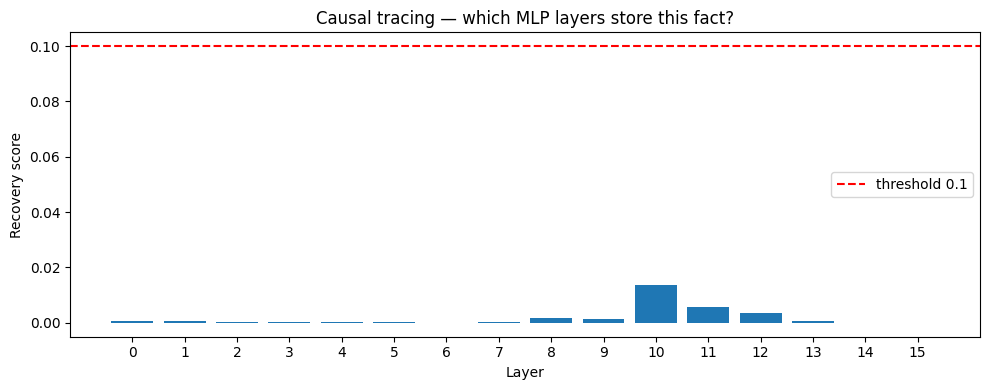


Critical layers (recovery > 0.1): []
Recommended  CFG.layers = []


In [10]:
import matplotlib.pyplot as plt
# ── Causal tracing — identify critical MLP layers ────────────────────────────
# This tells us WHICH layers actually store the fact we want to edit.
# Layers with recovery > 0.1 should be in CFG.layers.

test_prompt = "The mother tongue of Danielle Darrieux is"
test_answer = "French"
subject     = "Danielle Darrieux"

enc       = tokenizer(test_prompt, return_tensors='pt').to(GPU0)
answer_id = tokenizer(' ' + test_answer, add_special_tokens=False)['input_ids'][0]
n_layers  = model.config.num_hidden_layers

# Step 1: clean run
clean_mlp_outputs = {}
hooks = []
for i in range(n_layers):
    def make_hook(li):
        def hook(m, inp, out):
            clean_mlp_outputs[li] = out.detach().clone()
        return hook
    mod = get_module(model, f'model.layers.{i}.mlp')
    hooks.append(mod.register_forward_hook(make_hook(i)))
with torch.no_grad():
    clean_logits = model(**enc).logits[0, -1]
for h in hooks: h.remove()
clean_prob = torch.softmax(clean_logits, dim=-1)[answer_id].item()
print(f'Clean P("{test_answer}") = {clean_prob:.4f}')

# Step 2: corrupted run
subject_len = len(tokenizer(subject, return_tensors='pt')['input_ids'][0])
subj_end    = get_last_subject_pos(test_prompt, subject) + 1
subj_start  = max(0, subj_end - subject_len)

embed_mod  = get_module(model, 'model.embed_tokens')
def corrupt_hook(m, inp, out):
    out = out.clone()
    out[0, subj_start:subj_end] += torch.randn_like(out[0, subj_start:subj_end]) * 0.1
    return out
ch = embed_mod.register_forward_hook(corrupt_hook)
with torch.no_grad():
    corrupt_logits = model(**enc).logits[0, -1]
ch.remove()
corrupt_prob = torch.softmax(corrupt_logits, dim=-1)[answer_id].item()
print(f'Corrupted P("{test_answer}") = {corrupt_prob:.4f}')

# Step 3: patch each layer
restore_probs = []
for restore_layer in range(n_layers):
    ch = embed_mod.register_forward_hook(corrupt_hook)
    mod = get_module(model, f'model.layers.{restore_layer}.mlp')
    rh  = mod.register_forward_hook(lambda m,i,o,l=restore_layer: clean_mlp_outputs[l])
    with torch.no_grad():
        patched_logits = model(**enc).logits[0, -1]
    ch.remove(); rh.remove()
    pp = torch.softmax(patched_logits, dim=-1)[answer_id].item()
    recovery = (pp - corrupt_prob) / (clean_prob - corrupt_prob + 1e-8)
    restore_probs.append(recovery)
    print(f'  Layer {restore_layer:2d}: recovery={recovery:.3f}  {"█"*int(recovery*40)}')

fig, ax = plt.subplots(figsize=(10,4))
ax.bar(range(n_layers), restore_probs,
       color=['#d62728' if v > 0.1 else '#1f77b4' for v in restore_probs])
ax.axhline(0.1, color='red', linestyle='--', label='threshold 0.1')
ax.set_xlabel('Layer'); ax.set_ylabel('Recovery score')
ax.set_title('Causal tracing — which MLP layers store this fact?')
ax.set_xticks(range(n_layers)); ax.legend(); fig.tight_layout(); plt.show()

critical = [i for i,v in enumerate(restore_probs) if v > 0.1]
print(f'\nCritical layers (recovery > 0.1): {critical}')
print(f'Recommended  CFG.layers = {critical}')
# Optionally update:
# CFG.layers = critical


In [11]:
# ── Covariance estimation  C = E[kk^T]  (paper §4.2 eq.9) ───────────────────
# Ridge regularisation is *mandatory*: d_in=2048, samples~64k tokens.
# Without it C is near-singular → negative eigenvalues → broken closed-form.
# Fix: add eps*mean(diag(C))*I before inverting.

_cov_cache: Dict[int, torch.Tensor] = {}

def estimate_cov_inv(layer_idx: int) -> torch.Tensor:
    """Returns C⁻¹ on CPU.  Chunked accumulation avoids OOM on large d_in."""
    if layer_idx in _cov_cache:
        return _cov_cache[layer_idx]

    print(f'  [Cov] Layer {layer_idx} ...', end=' ', flush=True)
    mod  = get_module(model, CFG.mlp_module_tmp.format(layer_idx))
    d_in = mod.weight.shape[1]

    buf = []
    def hook(m, inp, out):
        buf.append(inp[0].detach().float().reshape(-1, d_in).cpu())
    h = mod.register_forward_hook(hook)

    # Try Wikipedia; fall back to CounterFact diverse texts
    texts = None
    try:
        from datasets import load_dataset
        ds    = load_dataset('wikipedia', '20220301.en', split='train', streaming=True)
        texts = [ex['text'][:256] for ex, _ in zip(ds, range(CFG.cov_n_texts))]
    except Exception:
        pass

    if texts is None:
        diverse = []
        for r in records:
            diverse += r.neighborhood_prompts + r.rephrase_prompts + r.generation_prompts
        for item in raw_cf[:500]:
            req  = item.get('requested_rewrite', {})
            subj = req.get('subject', '')
            p    = req.get('prompt', '{}').format(subj)
            if p: diverse.append(p)
            diverse += item.get('neighborhood_prompts', [])[:3]
        random.shuffle(diverse)
        texts = diverse[:CFG.cov_n_texts]
        print(f'(CF-diverse: {len(texts)} texts) ', end='')

    # Chunked accumulation — avoids building a huge matrix in one shot
    running = torch.zeros(d_in, d_in)
    total   = 0
    with torch.no_grad():
        for txt in texts:
            enc = tokenizer(txt, return_tensors='pt',
                            max_length=64, truncation=True).to(GPU0)
            model(**enc)
            if buf:
                k       = buf.pop()       # (T, d_in)
                running += k.T @ k        # accumulate outer products
                total   += k.shape[0]

    h.remove()

    C   = running / max(total, 1)
    eps = CFG.cov_ridge_eps * C.diagonal().mean().item()
    C_reg = C + eps * torch.eye(d_in, dtype=C.dtype)

    min_eig = torch.linalg.eigvalsh(C_reg).min().item()
    assert min_eig > 0, (
        f'C not PD after ridge! min_eig={min_eig:.6f}. '
        f'Increase CFG.cov_ridge_eps (currently {CFG.cov_ridge_eps})')

    C_inv = torch.linalg.inv(C_reg)
    _cov_cache[layer_idx] = C_inv
    print(f'done  eps={eps:.2e}  min_eig={min_eig:.2e}  samples={total}')
    return C_inv

print("Covariance ✓")


Covariance ✓


In [13]:
import random
# ── Auto-calibrate λ = mom2_update_weight  ────────────────────────────────────
# λ must be on the same scale as K^T C⁻¹K, otherwise the weight update is
# either crushed (λ too big) or unregularised (λ too small).
# We measure K^T C⁻¹K at the anchor layer for all edits, then set λ = 0.75 × median.

_cov_cache.clear()

layer0 = CFG.layers[0]
mod0   = get_module(model, CFG.mlp_module_tmp.format(layer0))
C_inv0 = estimate_cov_inv(layer0).float().to(GPU0)

ktck_vals = []
for req in edit_requests:
    s_pos   = get_last_subject_pos(req.prompt, req.subject)
    pmt_ids = tokenizer(req.prompt, return_tensors='pt')['input_ids'].to(GPU0)
    cap = {}
    def _h(m, inp, out, c=cap): c['k'] = inp[0].detach().float()
    hdl = mod0.register_forward_hook(_h)
    with torch.no_grad(): model(pmt_ids)
    hdl.remove()
    k = cap['k'][0, s_pos]
    ktck_vals.append((k @ C_inv0 @ k).item())

arr    = np.array(ktck_vals)
median = float(np.median(arr))
print(f'K^T C⁻¹K — min={arr.min():.1f}  median={median:.1f}  '
      f'mean={arr.mean():.1f}  max={arr.max():.1f}')

assert median > 0, (
    f'K^T C⁻¹K median is negative ({median:.2f}). '
    'Increase CFG.cov_ridge_eps and rerun this cell.')

CFG.mom2_update_weight = median * 0.75
_cov_cache.clear()
print(f'λ = {CFG.mom2_update_weight:.2f}  — cache cleared')


  [Cov] Layer 6 ... (CF-diverse: 1000 texts) done  eps=1.61e-05  min_eig=1.60e-05  samples=9309
K^T C⁻¹K — min=1751.7  median=6469.4  mean=7728.2  max=16553.6
λ = 4852.06  — cache cleared


In [14]:
# ── Stage 1: z-target optimisation  (paper §4.2 Eq.16) ──────────────────────
#
# Key improvements:
# FIX 1 — PREFIX AVERAGING (paper Eq.16): loss averaged over P context prefixes
#          Original used a single prompt (P=1), biasing z toward one surface form.
# FIX 2 — ANCHOR AT TOP LAYER L_max = layers[-1]:
#          Paper §4.3: zi must fully convey the memory at L = max(R).
#          Original anchored at layers[0] (bottom of R) — wrong.
# IMPROVEMENT — ReduceLROnPlateau scheduler for smoother convergence.

def compute_z_targets(requests: List[EditRequest],
                      prefixes: List[str]) -> torch.Tensor:
    anchor = CFG.layers[-1]                    # FIX 2
    lm     = get_module(model, CFG.layer_module_tmp.format(anchor))
    zs     = []

    for idx, req in enumerate(requests):
        print(f'  [z] ({idx+1}/{len(requests)}) "{req.prompt}" → "{req.target_new}"')

        tgt_ids        = tokenizer(' ' + req.target_new, add_special_tokens=False,
                                   return_tensors='pt')['input_ids'].to(GPU0)
        pmt_ids_plain  = tokenizer(req.prompt, return_tensors='pt')['input_ids'].to(GPU0)
        s_pos_plain    = get_last_subject_pos(req.prompt, req.subject)
        full_ids_plain = torch.cat([pmt_ids_plain, tgt_ids], dim=1)

        # Build P prefix variants once per request
        prompt_variants = [p + req.prompt for p in prefixes]

        # Baseline h0 at anchor layer
        cap = {}
        def snap(m, inp, out, c=cap):
            c['h'] = (out[0] if isinstance(out, tuple) else out).detach()
        hdl = lm.register_forward_hook(snap)
        with torch.no_grad(): model(full_ids_plain)
        hdl.remove()
        h0    = cap['h'][0, s_pos_plain].float().clone()
        delta = torch.zeros_like(h0, requires_grad=True)

        opt   = torch.optim.Adam([delta], lr=CFG.v_lr, weight_decay=CFG.v_weight_decay)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    opt, mode='min', factor=0.5, patience=8, min_lr=1e-4)

        best_loss = float('inf')
        for step in range(CFG.v_num_grad_steps):
            opt.zero_grad()
            total_ce = torch.tensor(0.0, device=GPU0)
            total_kl = torch.tensor(0.0, device=GPU0)

            for pv in prompt_variants:            # FIX 1: iterate over prefixes
                pmt_ids_v  = tokenizer(pv, return_tensors='pt')['input_ids'].to(GPU0)
                full_ids_v = torch.cat([pmt_ids_v, tgt_ids], dim=1)
                prefix_len = pmt_ids_v.shape[1] - pmt_ids_plain.shape[1]
                s_pos_v    = s_pos_plain + prefix_len

                def patch(m, inp, out, sp=s_pos_v, d=delta):
                    h  = (out[0] if isinstance(out, tuple) else out).float().clone()
                    h[0, sp] = h[0, sp] + d
                    dt = out[0].dtype if isinstance(out, tuple) else out.dtype
                    h  = h.to(dt)
                    return (h,) + out[1:] if isinstance(out, tuple) else h

                ph  = lm.register_forward_hook(patch)
                log = model(full_ids_v).logits[0].float()
                ph.remove()

                t0_ = pmt_ids_v.shape[1]
                total_ce = total_ce + F.cross_entropy(
                    log[t0_-1 : t0_-1 + tgt_ids.shape[1]], tgt_ids[0])

                with torch.no_grad():
                    ref = model(full_ids_v).logits[0].float()
                total_kl = total_kl + CFG.kl_factor * F.kl_div(
                    torch.log_softmax(log[:t0_], dim=-1),
                    torch.softmax(ref[:t0_],  dim=-1),
                    reduction='batchmean')

            # FIX 1: average over P prefixes (Eq.16: 1/P Σⱼ)
            ce = total_ce / len(prompt_variants)
            kl = total_kl / len(prompt_variants)
            loss = ce + kl
            loss.backward()

            # Norm clamping on delta (paper §4.2)
            with torch.no_grad():
                max_norm = CFG.clamp_norm_factor * h0.norm()
                if delta.norm() > max_norm:
                    delta.data = delta.data * max_norm / (delta.norm() + 1e-8)

            opt.step()
            sched.step(ce.item())
            best_loss = min(best_loss, ce.item())

            if step % 25 == 0:
                lr = opt.param_groups[0]['lr']
                print(f'      step {step:3d} | CE={ce.item():.3f}  '
                      f'KL={kl.item():.4f}  lr={lr:.5f}')

        d_norm = delta.detach().norm().item()
        h_norm = h0.norm().item()
        print(f'      δ norm={d_norm:.3f}  h0 norm={h_norm:.3f}  '
              f'ratio={d_norm/(h_norm+1e-8):.3f}  best_CE={best_loss:.3f}')

        zs.append((h0 + delta.detach()).cpu())
        gc.collect(); torch.cuda.empty_cache()

    return torch.stack(zs)   # (n, d_model) on CPU

print("z-optimiser (prefix-averaged, top-anchor, LR scheduler) ✓")


z-optimiser (prefix-averaged, top-anchor, LR scheduler) ✓


In [15]:
# ── Stage 2: Closed-form weight update  (paper §4.3 Eq.14 + Eq.20) ──────────
#
# FIX 3 — PREFIX-AVERAGED KEY VECTORS (paper §4.2 Eq.19):
#   kˡᵢ = (1/P) Σⱼ k(xⱼ ⊕ sᵢ)
#   Keys are averaged over the same P prefixes as z-targets.
#
# FIX 4 — RESIDUAL SPREADING (paper §4.3 Eq.20):
#   Each layer l ∈ R handles only its share of the residual:
#   rˡᵢ = (zᵢ − hᴸᵢ_current) / (L_max − l + 1)
#   This distributes the memory update instead of having one layer do all the work.

def compute_delta_W(requests, z_targets, layer_idx, C_inv,
                    h_current, L_max, prefixes) -> torch.Tensor:
    mod = get_module(model, CFG.mlp_module_tmp.format(layer_idx))
    dev = mod.weight.device
    W0  = mod.weight.float()

    # FIX 3: prefix-averaged key vectors
    keys = []
    for req in requests:
        pmt_ids_plain = tokenizer(req.prompt, return_tensors='pt')['input_ids'].to(dev)
        s_pos_plain   = get_last_subject_pos(req.prompt, req.subject)
        key_acc       = torch.zeros(mod.weight.shape[1], dtype=torch.float32)

        for pv in prefixes:
            pmt_ids_v  = tokenizer(pv + req.prompt,
                                   return_tensors='pt')['input_ids'].to(dev)
            prefix_len = pmt_ids_v.shape[1] - pmt_ids_plain.shape[1]
            s_pos_v    = s_pos_plain + prefix_len

            cap = {}
            def hook(m, inp, out, c=cap): c['k'] = inp[0].detach().float()
            hdl = mod.register_forward_hook(hook)
            with torch.no_grad(): model(pmt_ids_v)
            hdl.remove()
            key_acc += cap['k'][0, s_pos_v].cpu()

        keys.append(key_acc / len(prefixes))

    K  = torch.stack(keys, dim=1).to(dev)   # (d_in, n)
    Ci = C_inv.float().to(dev)              # (d_in, d_in)

    # FIX 4: per-layer residual spreading  rˡ = (z − h) / (L_max − l + 1)
    denominator = L_max - layer_idx + 1
    Z_t = z_targets.float().to(dev)         # (n, d_model)
    H_c = h_current.float().to(dev)         # (n, d_model)
    R   = ((Z_t - H_c) / denominator).T     # (d_out, n)

    # Closed-form: ΔW = R (K^T C⁻¹K + λI)⁻¹ K^T C⁻¹  (Eq.14)
    CiK = Ci @ K                             # (d_in, n)
    A   = K.T @ CiK + CFG.mom2_update_weight * torch.eye(
              K.shape[1], device=dev, dtype=torch.float32)  # (n, n)
    dW  = R @ torch.linalg.solve(A.T, CiK.T)               # (d_out, d_in)

    # Safety clamp: don't let ΔW dominate W0
    scale = W0.norm() / (dW.norm() + 1e-8)
    if scale < CFG.clamp_norm_factor:
        dW = dW * (scale / CFG.clamp_norm_factor)

    return dW

print("Weight-update solver (prefix-averaged keys + residual spreading) ✓")


Weight-update solver (prefix-averaged keys + residual spreading) ✓


In [16]:
# ── apply_memit + batched wrapper ────────────────────────────────────────────
#
# FIX 5 — ACTIVATION RE-COLLECTION BETWEEN LAYERS (paper Figure 4 §4.3):
#   After updating layer l, h_current at L_max changes because earlier layers
#   now output different values.  We re-run the model to get fresh activations
#   so each layer's residual reflects what prior layers already contributed.

def collect_hidden_states(requests: List[EditRequest],
                          layer_idx: int) -> torch.Tensor:
    lm  = get_module(model, CFG.layer_module_tmp.format(layer_idx))
    hs  = []
    for req in requests:
        s_pos    = get_last_subject_pos(req.prompt, req.subject)
        pmt_ids  = tokenizer(req.prompt, return_tensors='pt')['input_ids'].to(GPU0)
        tgt_ids  = tokenizer(' ' + req.target_new, add_special_tokens=False,
                             return_tensors='pt')['input_ids'].to(GPU0)
        full_ids = torch.cat([pmt_ids, tgt_ids], dim=1)

        cap = {}
        def snap(m, inp, out, c=cap):
            c['h'] = (out[0] if isinstance(out, tuple) else out).detach().float()
        hdl = lm.register_forward_hook(snap)
        with torch.no_grad(): model(full_ids)
        hdl.remove()
        hs.append(cap['h'][0, s_pos].cpu())

    return torch.stack(hs)   # (n, d_model)


def apply_memit(requests: List[EditRequest]):
    """Run MEMIT on one batch of requests."""
    print(f'\n=== MEMIT | edits={len(requests)} | layers={CFG.layers} '
          f'| λ={CFG.mom2_update_weight:.1f} ===')

    prefixes = PREFIX_BANK[:CFG.v_num_prefixes]
    L_max    = CFG.layers[-1]

    # ── Stage 1 ───────────────────────────────────────────────────────────────
    print('\n[1/2] z-target optimisation ...')
    z = compute_z_targets(requests, prefixes)
    assert z.shape[0] == len(requests)
    print(f'  z shape: {z.shape}')

    # ── Stage 2 ───────────────────────────────────────────────────────────────
    print('\n[2/2] Closed-form weight update ...')
    h_current = collect_hidden_states(requests, L_max)

    for layer in CFG.layers:
        C_inv = estimate_cov_inv(layer)
        dW    = compute_delta_W(
                    requests, z, layer, C_inv,
                    h_current = h_current,
                    L_max     = L_max,
                    prefixes  = prefixes)

        mod = get_module(model, CFG.mlp_module_tmp.format(layer))
        with torch.no_grad():
            mod.weight.add_(dW.to(mod.weight.dtype))
        print(f'  Layer {layer}: ΔW norm = {dW.norm():.4f}')

        # FIX 5: re-collect activations through updated weights
        if layer != CFG.layers[-1]:
            h_current = collect_hidden_states(requests, L_max)
            print(f'    → activations re-collected after layer {layer}')

        gc.collect(); torch.cuda.empty_cache()

    print('\nBatch edit complete ✓')


def apply_memit_batched(requests: List[EditRequest]):
    total     = len(requests)
    bs        = CFG.batch_size
    n_batches = (total + bs - 1) // bs
    print(f'\nRunning {total} edits in {n_batches} batches of ≤{bs}')

    for i in range(0, total, bs):
        batch = requests[i : i + bs]
        print(f'\n{"="*60}')
        print(f'Batch {i//bs+1}/{n_batches}  '
              f'(requests {i+1}–{min(i+bs,total)} of {total})')
        print(f'{"="*60}')
        apply_memit(batch)

    print(f'\n✓ All {total} edits complete.')

print("apply_memit ✓")


apply_memit ✓


In [17]:
# PRE-edit baseline
print('PRE-edit log-probs (first 3):')
pre_lp = []
for r in records[:3]:
    lp = token_log_prob(r.prompt, r.target_new)
    pre_lp.append(lp)
    print(f'  "{r.prompt}" → "{r.target_new}" : {lp:.3f}')

# ── Run MEMIT ─────────────────────────────────────────────────────────────────
t0 = time.time()
apply_memit_batched(edit_requests)
elapsed = time.time() - t0
print(f'\nTotal time: {elapsed:.1f}s  ({elapsed/len(edit_requests):.2f}s/edit)')

# POST-edit check
print('\nPOST-edit log-probs (first 3):')
for r, pre in zip(records[:3], pre_lp):
    post = token_log_prob(r.prompt, r.target_new)
    ok   = '✓' if post > pre else '✗'
    print(f'  {ok} pre={pre:.3f}  post={post:.3f}  Δ={post-pre:+.3f}  "{r.prompt[:50]}"')


PRE-edit log-probs (first 3):
  "The mother tongue of Danielle Darrieux is" → "English" : -4.086
  "The official religion of Edwin of Northumbria is" → "Islam" : -5.633
  "Toko Yasuda, the" → "piano" : -10.828

Running 10 edits in 1 batches of ≤10

Batch 1/1  (requests 1–10 of 10)

=== MEMIT | edits=10 | layers=[6, 7, 8, 9, 10, 11] | λ=4852.1 ===

[1/2] z-target optimisation ...
  [z] (1/10) "The mother tongue of Danielle Darrieux is" → "English"
      step   0 | CE=4.070  KL=-0.0000  lr=0.01000
      step  25 | CE=0.048  KL=0.0186  lr=0.01000
      step  50 | CE=0.064  KL=0.0152  lr=0.00500
      step  75 | CE=0.063  KL=0.0156  lr=0.00063
      δ norm=2.954  h0 norm=9.224  ratio=0.320  best_CE=0.039
  [z] (2/10) "The official religion of Edwin of Northumbria is" → "Islam"
      step   0 | CE=5.675  KL=-0.0000  lr=0.01000
      step  25 | CE=0.010  KL=0.0254  lr=0.01000
      step  50 | CE=0.029  KL=0.0186  lr=0.00250
      step  75 | CE=0.035  KL=0.0176  lr=0.00031
      δ norm=3.642 

In [18]:
# ── Comprehensive evaluation  (paper §5.1) ────────────────────────────────────
def run_eval(eval_recs: List[CFRecord]) -> dict:
    es, ps, ns, gs = [], [], [], []

    for r in eval_recs:
        def top1_is_target(prompt, target):
            enc    = tokenizer(prompt, return_tensors='pt').to(GPU0)
            with torch.no_grad():
                logits = model(**enc).logits[0, -1]
            top1_id = logits.argmax().item()
            tgt_id  = tokenizer(' ' + target, add_special_tokens=False)['input_ids'][0]
            return int(top1_id == tgt_id)

        def norm_lp(prompt, target):
            return token_log_prob(prompt, target)

        def lp_wins(prompt, tgt_new, tgt_true):
            return int(norm_lp(prompt, tgt_new) > norm_lp(prompt, tgt_true))

        # Efficacy: does the edited prompt output the new target?
        es.append(top1_is_target(r.prompt, r.target_new))

        # Paraphrase: does the edit generalise to rephrasings?
        for rp in r.rephrase_prompts[:3]:
            ps.append(lp_wins(rp, r.target_new, r.ground_truth))

        # Neighbourhood: are unrelated facts left unchanged?
        for np_p in r.neighborhood_prompts[:5]:
            enc    = tokenizer(np_p, return_tensors='pt').to(GPU0)
            with torch.no_grad():
                logits = model(**enc).logits[0, -1]
            top1_id = logits.argmax().item()
            new_id  = tokenizer(' ' + r.target_new, add_special_tokens=False)['input_ids'][0]
            ns.append(int(top1_id != new_id))

        # Generation: do generation prompts also reflect the edit?
        for gp in r.generation_prompts[:3]:
            gs.append(lp_wins(gp, r.target_new, r.ground_truth))

    ES = float(np.mean(es)) if es else 0.0
    PS = float(np.mean(ps)) if ps else 0.0
    NS = float(np.mean(ns)) if ns else 0.0
    GS = float(np.mean(gs)) if gs else 0.0
    HM = 3 / (1/(ES+1e-9) + 1/(PS+1e-9) + 1/(NS+1e-9))
    return dict(efficacy=ES, paraphrase=PS, neighbourhood=NS,
                generation=GS, editing_score_HM=HM)

metrics = run_eval(records[:EVAL_N])
print('\n' + '='*48)
print(f'  {"Metric":<22} {"Score":>6}  Bar')
print('-'*48)
for k, v in metrics.items():
    bar = '█' * int(v * 30)
    print(f'  {k:<22} {v:>6.3f}  {bar}')
print('='*48)



  Metric                  Score  Bar
------------------------------------------------
  efficacy                0.500  ███████████████
  paraphrase              0.250  ███████
  neighbourhood           0.960  ████████████████████████████
  generation              0.033  █
  editing_score_HM        0.426  ████████████


In [19]:
# ── Per-edit rank inspection ──────────────────────────────────────────────────
print(f'{"prompt":<45} {"new_rank":>8} {"gap":>8} {"top1":>12}')
print('-'*80)

for r in records[:EVAL_N]:
    enc = tokenizer(r.prompt, return_tensors='pt').to(GPU0)
    with torch.no_grad():
        logits = model(**enc).logits[0, -1]
    new_id    = tokenizer(' ' + r.target_new, add_special_tokens=False)['input_ids'][0]
    top1_id   = logits.argmax().item()
    top1_str  = tokenizer.decode([top1_id]).strip()
    sorted_ids = logits.argsort(descending=True).tolist()
    new_rank  = sorted_ids.index(new_id) + 1
    gap       = logits[new_id].item() - logits[top1_id].item()
    ok        = '✓' if new_rank == 1 else '✗'
    print(f'{ok} {r.prompt[:44]:<44} {new_rank:>8} {gap:>8.3f} {top1_str:>12}')

prompt                                        new_rank      gap         top1
--------------------------------------------------------------------------------
✓ The mother tongue of Danielle Darrieux is           1    0.000      English
✓ The official religion of Edwin of Northumbri        1    0.000        Islam
✗ Toko Yasuda, the                                 2615   -7.438             
✗ Autonomous University of Madrid, which is lo       89   -7.484          the
✓ What is the twin city of Lyon? It is                1    0.000       Manila
✓ The mother tongue of Thomas Joannes Stieltje        1    0.000      English
✗ Anaal Nathrakh, that was created in               151   -8.570             
✗ Apple A5 was created by                           145   -6.727        Apple
✓ What is the twin city of Wellington? It is          1    0.000    Sheffield
✗ Shree Pundalik, created in                        314   -8.945             


In [ ]:
print(f'{"prompt":<45} {"new_rank":>8} {"gap":>8} {"top1":>12}')
print('-'*80)

for r in records[:10]:
    enc    = tokenizer(r.prompt, return_tensors='pt').to(GPU0)
    with torch.no_grad():
        logits = model(**enc).logits[0, -1]
    new_id   = tokenizer(' ' + r.target_new,  add_special_tokens=False)['input_ids'][0]
    top1_id  = logits.argmax().item()
    top1_str = tokenizer.decode([top1_id]).strip()
    sorted_ids = logits.argsort(descending=True).tolist()
    new_rank   = sorted_ids.index(new_id) + 1
    gap        = logits[new_id].item() - logits[top1_id].item()
    print(f'{r.prompt[:45]:<45} {new_rank:>8} {gap:>8.3f} {top1_str:>12}')

# MEMIT on LLaMA 3.2-1B × CounterFact

Implementation of **Mass-Editing Memory In a Transformer (MEMIT)**  
[Meng et al., ICLR 2023](https://arxiv.org/pdf/2210.07229) adapted for **LLaMA 3.2-1B**.

---

## Files

| File | Purpose |
|------|---------|
| `memit_editor.py` | Core algorithm: config, covariance estimation, z-target optimisation, weight update |
| `counterfact_eval.py` | CounterFact loader + efficacy / generalization / specificity metrics |
| `run_experiment.py` | End-to-end experiment runner with CLI |
| `requirements.txt` | Python dependencies |

---

## Algorithm (paper §4)

```
MEMIT(E = {(s_i, r_i, o_i)}, R = critical MLP layers)
  For each edit i:
    1. Optimise delta_i so that inserting it at layer R[0], position h^l_{[S]},
       causes the model to predict o_i*  (finding z_i, §4.2)
  For each layer l ∈ R:
    2. Collect key vectors K = [k_1, ..., k_n]  (inputs to W_out at h^l_{[S]})
    3. Estimate C = E[k k^T] from Wikipedia text  (covariance, §4.2 eq.9)
    4. Solve ΔW = (Z - W₀K)(K^T C⁻¹ K + λI)⁻¹ K^T C⁻¹   (eq.9)
    5. W_out ← W_out + ΔW
```

Key insight: distributing the update across **multiple layers** (instead of a
single rank-1 update as in ROME) allows thousands of edits without degradation.

---

## Evaluation Metrics (paper §5.1)

| Metric | Definition |
|--------|-----------|
| **Efficacy Score (ES)** | P(o* \| prompt) > P(o_old \| prompt) |
| **Paraphrase Score (PS)** | ES on rephrased prompts (generalization) |
| **Neighbourhood Score (NS)** | Nearby subjects still predict old answer (specificity) |
| **Editing Score** | Harmonic mean of ES, PS, NS |

---

## Quick Start

```bash
# 1. Install deps
pip install -r requirements.txt

# 2. Authenticate with HuggingFace (LLaMA 3.2-1B requires acceptance of licence)
huggingface-cli login

# 3. Smoke test – 5 edits
python run_experiment.py --n_edits 5

# 4. Larger experiment – 200 edits, batches of 50
python run_experiment.py --n_edits 200 --batch_size 50

# 5. With fp16 (saves VRAM)
python run_experiment.py --n_edits 100 --fp16
```

Results are saved to `results/memit_results.json`.

---

## LLaMA 3.2-1B Layer Selection

LLaMA 3.2-1B has **16 transformer layers**.  
Causal mediation analysis (paper §4.1) identifies mid-range MLP layers as
critical factual mediators. Default: `--layers 4,5,6,7,8`.

To run a quick causal trace yourself, increase `--v_steps` and watch which
layers show the strongest efficacy gain.

---

## Hardware

| Setup | VRAM | Speed |
|-------|------|-------|
| A100 40 GB, fp32 | ~8 GB | ~2 s/edit |
| T4 16 GB, fp16 | ~4 GB | ~5 s/edit |
| CPU only | – | ~60 s/edit |

---

## Citation

```bibtex
@inproceedings{meng2023memit,
  title     = {Mass-Editing Memory in a Transformer},
  author    = {Meng, Kevin and Sen Sharma, Arnab and Andonian, Alex
               and Belinkov, Yonatan and Bau, David},
  booktitle = {ICLR},
  year      = {2023},
  url       = {https://arxiv.org/abs/2210.07229}
}
```